# Scientific Computing Project #1

---------------

**Author:** *Salvador Palma* (mtr765) <br>
**Institution:** UCPH - University of Copenhagen

In [81]:
from watermatrices import Amat, Bmat, yvec
import numpy as np

In [82]:
print(f"Matrix A: {Amat.shape}")
print(f"Matrix B: {Bmat.shape}")
print(f"Vector Y: {yvec.shape}")

Matrix A: (7, 7)
Matrix B: (7, 7)
Vector Y: (7,)


In [83]:
dim = Amat.shape[0]

E = np.block([[Amat, Bmat], [Bmat, Amat]])

I = np.eye(dim)
O = np.zeros((dim, dim))

S = np.block([[I, O], [O, -I]])

z = np.concatenate((yvec, -yvec))

print(f"Matrix E: {E.shape}")
#print(f"Matrix E:\n{E}")
print("\n")

print(f"Matrix S: {S.shape}")
#print(f"Matrix S:\n{S}")
print("\n")

print(f"Vector z: {z.shape}")
print(f"Vector z:\n{z}")

Matrix E: (14, 14)


Matrix S: (14, 14)


Vector z: (14,)
Vector z:
[-0.057 -0.009  0.16   0.07   0.678 -0.109  0.905  0.057  0.009 -0.16
 -0.07  -0.678  0.109 -0.905]


## Week 1

### Exercise a)

#### (1) 

The function `conditionNumber(M)` follows the equation:

$$ ||A||_\infty = max_i \sum\limits_{j=1}^n |a_{ij}|$$

to compute the matrix norm, and then applies the one given in the exercise:

$$ cond_\infty(M) = ||M||_\infty \cdot ||M^{-1}||_\infty $$

In [84]:
def infNorm(M):
    return np.max(np.sum(np.abs(M), axis=1))

def conditionNumber(M):
    M_inv = np.linalg.inv(M)

    maxValOg = infNorm(M)
    maxValInv = infNorm(M_inv)
    
    return maxValOg * maxValInv

#### (2)

Given that the only non-exact input is the right-hand side `z`, with 8 significant digits, its relative error is bounded by $\frac{||\Delta z||_\infty}{||z||_\infty} \le \frac{1}{2}10^{-8}$, and this error associates to the solution `x` via

$$\frac{||\Delta x||_\infty}{||x||_\infty} \le \text{cond}_\infty(E-\omega S)\cdot\frac{||\Delta z||_\infty}{||z||_\infty} \le \text{cond}_\infty(E-\omega S)\cdot \frac{1}{2}10^{-8}$$

This means that the condition number acts as an amplification factor, that is, it measures how much a relative error in the input increases in the output. To calculate the amount of decimal digits we can guarantee in the solution `x`, we can leverage the following formula based on the relative error just calculated:

$$ \text{Guaranteed Digits} = \lfloor-\log_{10} |E_{rel}|\rfloor$$

which leads us to the results depicted below:

| $\omega$ | $\text{cond}_\infty(E- \omega S) $ | upper bound | guaranteed digits in `x` |
| --- | --- | --- | --- |
| 0.800 | 327.82 | 1.64e-06 | **5** |
| 1.146 | 152679.27 | 7.63e-04 | **3** |
| 1.400 | 227.19 | 1.14e-06 | **5** |

In [85]:
ws = [0.800, 1.146, 1.400]

for w in ws:
    M = E - w * S
    condN = conditionNumber(M)
    print(f"w={w:.3f}")
    print(f"condition number = {condN:.2f}")
    print(f"upper bound = {condN*0.5e-8:.2e}")
    print(f"guaranteed digits = {np.floor(-np.log10(abs(condN*0.5e-8)))}")
    print("\n")

w=0.800
condition number = 327.82
upper bound = 1.64e-06
guaranteed digits = 5.0


w=1.146
condition number = 152679.27
upper bound = 7.63e-04
guaranteed digits = 3.0


w=1.400
condition number = 227.19
upper bound = 1.14e-06
guaranteed digits = 5.0




### Exercise b)

#### (1)

For each $\omega$, we determine the bound on the relative forward error via:

$$ \frac{||\Delta x||_\infty}{||\hat{x}||_\infty} \le \text{cond}_\infty (E - \omega S) \cdot \frac{||\delta \omega S||_\infty}{||E - \omega S||_\infty}$$

as $\omega$ is given with 3 decimal digits, we know that the perturbation $\delta \omega$ shall be $\frac{1}{2} \cdot 10^{-3}$, the bounds are as follows:

| $\omega$ | bound |
|---|---|
| 0.800 | 0.00522|
| 1.146 | 2.40504 |
| 1.400 | 0.00355 |

In [86]:
for w in ws:
    M = E - w * S
    condN = conditionNumber(M)
    upper = infNorm(0.0005 * S)
    lower = infNorm(M)
    upperBound = condN * (upper / lower)
    print(f"w={w:.3f} upper bound = {upperBound:.5f}")


w=0.800 upper bound = 0.00522
w=1.146 upper bound = 2.40504
w=1.400 upper bound = 0.00355


#### (2)

Using the upper bounds for the relative errors that we just calculated, and the following formula:

$$ \text{Guaranteed Digits} = \lfloor-\log_{10} |E_{rel}|\rfloor$$

We can calculate the amount of significant digits that we can guarantee in `x`, leading to the following results

| $\omega$ | guaranteed digits |
|---|---|
| 0.800 | 2|
| 1.146 | 0 |
| 1.400 | 2 |

*Note: $\omega=1.146$ actually leads to the equation above to equal $-1$, but this is the same as saying we can't guarantee **any** decimal digit*

In [87]:
for w in ws:
    M = E - w * S
    condN = conditionNumber(M)
    upper = infNorm(0.0005 * S)
    lower = infNorm(M)
    upperBound = condN * (upper / lower)
    
    guaranteedDigits = np.floor(-np.log10(abs(upperBound)))
    guaranteedDigits = max(0, guaranteedDigits)
    print(f"w={w:.3f} guaranteed digits = {guaranteedDigits:.0f}")

w=0.800 guaranteed digits = 2
w=1.146 guaranteed digits = 0
w=1.400 guaranteed digits = 2


### Exercise c)

The function `lu_factorize(M)` takes in a square matrix `M` and computes its LU factorization, in such a way that M = LU. In the output cell below we can observe that same verification, where `l @ u` yielded the same matrix as `testMatrix`. 

The functions `forward_substitute(L, b)` and `back_substitute(U, y)` leverage the $LU$ matrices to reach the same solution as the original `Mx = b`. The former yields the solution vector `y` in `Ly = b`, whilst the latter yields the solution vector `x` in `Ux = y`. To verify, we can compare against the direct solution from built-in libraries.

In [88]:
def lu_factorize(M):
    assert M.shape[0] == M.shape[1], "Matrix ain't there, be square"

    n = M.shape[0]
    U = M.astype(float).copy()
    L = np.eye(n)
    for i in range(n):
        if U[i, i] == 0:
            raise ZeroDivisionError(f"zero pivot at index {i}: LU without pivoting fails")
        L[i+1:, i]   = U[i+1:, i] / U[i, i]               # every multiplier of column i at once
        U[i+1:, i:] -= np.outer(L[i+1:, i], U[i, i:])      # rank-1 update of the remaining submatrix
        U[i+1:, i]   = 0.0                                 # exact zeros below the diagonal
    return L, U

testMatrix = np.array([[2, 1, 1], [4, 1, 4], [-6, -5, 3]], dtype=float)
testRHS    = np.array([4, 11, 4], dtype=float)

l, u = lu_factorize(testMatrix)

print("---- Lower ----")
print(l)
print("---- Upper ----")
print(u)
print("---- Check: L @ U ----")
print(l @ u)

---- Lower ----
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-3.  2.  1.]]
---- Upper ----
[[ 2.  1.  1.]
 [ 0. -1.  2.]
 [ 0.  0.  2.]]
---- Check: L @ U ----
[[ 2.  1.  1.]
 [ 4.  1.  4.]
 [-6. -5.  3.]]


In [89]:
def forward_substitute(L, b):
    n = L.shape[0]
    y = np.zeros(n, dtype=float)
    for k in range(n):  
        if L[k, k] == 0:
            raise ZeroDivisionError(f"singular L at index {k}")
        y[k] = (b[k] - L[k, :k] @ y[:k]) / L[k, k]
    return y

def back_substitute(U, y):
    n = U.shape[0]
    x = np.zeros(n, dtype=float)
    for k in range(n-1, -1, -1):        
        if U[k, k] == 0:
            raise ZeroDivisionError(f"singular U at index {k}")
        x[k] = (y[k] - U[k, k+1:] @ x[k+1:]) / U[k, k]
    return x

y = forward_substitute(l, testRHS)
x = back_substitute(u, y)

print(f"y   (solves L y = b) = {y}")
print(f"x   (solves U x = y) = {x}")
print()
print(f"numpy y              = {np.linalg.solve(l, testRHS)}")
print(f"numpy x              = {np.linalg.solve(testMatrix, testRHS)}")
print(f"max |x - numpy x|    = {np.max(np.abs(x - np.linalg.solve(testMatrix, testRHS))):.2e}")

y   (solves L y = b) = [ 4.  3. 10.]
x   (solves U x = y) = [-4.  7.  5.]

numpy y              = [ 4.  3. 10.]
numpy x              = [-4.  7.  5.]
max |x - numpy x|    = 8.88e-16


### Exercise d)

#### (1)

The function `solve_alpha(omega)` computes $\alpha (\omega)$ by the equation $\alpha (\omega) = \text{z}^T \text{x}$. To find $\text{x}$, it LU-factorizes $E - \omega S$, forward, and back substitutes, all with the functions from the previous exercise, so that

$$ (\mathbf{E}-\omega\mathbf{S})\,\mathbf{x} = \mathbf{z}$$


Then, we compute a table of polarizabilities,  with $\delta\omega = \tfrac{1}{2}\cdot 10^{-3}$:

| $\omega$ |$\alpha(\omega-\delta\omega)$ | $\alpha(\omega)$ | $\alpha(\omega+\delta\omega)$ |
| --- | --- | --- | --- |
| 0.800 |1.6278 | 1.6361 |1.6444|
| 1.146 |994.7530 |2609.2353| -4185.0185 |
| 1.400 |-2.7139 | -2.7069 |-2.6999 |

In [90]:
def solve_alpha(omega):
    A = E - omega * S
    L, U = lu_factorize(A)
    y = forward_substitute(L, z)
    x = back_substitute(U, y)

    return z.transpose() @ x

dw = 0.5e-3

for w in ws:
    print(f"w={w:.3f}")
    print(f"a(w-dw) = {solve_alpha(w - dw):.4f}")
    print(f"a(w) = {solve_alpha(w):.4f}")
    print(f"a(w+dw) = {solve_alpha(w + dw):.4f}")
    print("\n")

w=0.800
a(w-dw) = 1.6278
a(w) = 1.6361
a(w+dw) = 1.6444


w=1.146
a(w-dw) = 994.7530
a(w) = 2609.2353
a(w+dw) = -4185.0183


w=1.400
a(w-dw) = -2.7139
a(w) = -2.7069
a(w+dw) = -2.6999




#### (2)

The two bounds at hand answer to different problems. Bound (a) relates to the error in the input `z`, which is given with 8 significant digits, making every computed $\alpha(\omega)$ carry that same constant uncertainty independent of if we are dealing with $\omega$ or its variations $\omega \pm \delta$. Therefore it doesn't answer nothing regarding the variation deu to the perturbation $\delta$. Bound (b), on the other hand, is another story. The perturbation $\delta$ changes the matrix $E - \omega S$ by $- \delta S$, rather than the right-hand side `z`. And the bound given in (b) is exactly what relates this difference to the final output `x`.

To sum up, the error-bound that is correct to understand the variation of the calculated polarizabilities due to the perturbation $\delta$ is (b) and (b) only.

#### (3)

As stated just now, $\omega$ does not affect the input `z`, therefore, we can consider the `x` in $\alpha(\omega) = z^T x$ as a function of $\omega$, that is $x(\omega)$. With this in mind, we can expand the $\Delta \alpha(\omega)$ expression to

$$\Delta \alpha(\omega) = \alpha(\omega + \delta\omega) - \alpha(\omega) = z^Tx(\omega + \delta\omega) - z^Tx(\omega) = z^T \Delta x$$

in which $\Delta x = x(\omega+\delta\omega) - x(\omega)$


The target form has $| \alpha( \omega) |$, which expanding into the sum of the individual entries of `z` and `x` lets us say that:

$$| \alpha( \omega) | = | \sum\limits_i z_i \Delta x_i|  $$

Considering the summatory triangle inequality and the fact that any element of `x` is lesser or equal than the norm (i.e. $|x_i| \le ||x||_\infty$), we develop into

$$ | \sum\limits_i z_i \Delta x_i|  \le \sum\limits_i |z_i| |\Delta x_i| \le (\sum\limits_i |z_i|) ||\Delta x||_\infty$$


In the equation in (b), we saw that the matrix is disturbed by $\delta \omega S$. However, since the matrix `S` is only represented by either 1 or -1, we know that its norm will simply be the absolute of the perturbation, that is, $||\delta \omega S ||_\infty = |\delta\omega| $. So we can rewrite the equation as

$$ \frac{||\Delta x||_\infty}{||\hat{x}||_\infty} \le \text{cond}_\infty (E - \omega S) \cdot \frac{|\delta \omega |}{||E - \omega S||_\infty}$$

And with some more basic math, we get

$$ \equiv ||\Delta x||_\infty \le ||\hat{x}||_\infty \cdot \text{cond}_\infty (E - \omega S) \cdot \frac{|\delta \omega |}{||E - \omega S||_\infty}$$

$$ \equiv (\sum\limits_i |z_i|) \cdot ||\Delta x||_\infty \le (\sum\limits_i |z_i|) \cdot ||\hat{x}||_\infty \cdot \text{cond}_\infty (E - \omega S) \cdot \frac{|\delta \omega |}{||E - \omega S||_\infty}$$

$$ \equiv | \Delta\alpha( \omega) | \le (\sum\limits_i |z_i|) \cdot ||\hat{x}||_\infty \cdot \text{cond}_\infty (E - \omega S) \cdot \frac{|\delta \omega |}{||E - \omega S||_\infty}$$

$$ \equiv | \Delta\alpha( \omega) | \le B(\omega) \cdot | \delta \omega |, \qquad B(\omega) = (\sum\limits_i |z_i|) \cdot ||\hat{x}||_\infty \cdot   \frac{\text{cond}_\infty (E - \omega S)}{||E - \omega S||_\infty}$$

Which is the exact bound form we aimed for!

After implementing it in code, we get the following values, meaning our calculated values do fall within the bound correctly


| $\omega$ | $\delta\omega$ |  $B(\omega)\,\lvert\delta\omega\rvert$ | $\lvert\Delta\alpha\rvert$ | Passed |
| --- | --- | --- | --- | --- |
| 0.800 | + | 6.59e-02 | 8.29e-03 | Yes | 
| 0.800 |- | 6.59e-02 | 8.32e-03 |Yes |
| 1.146 | + | 2.72e+04 | 6.79e+03 | Yes |
| 1.146 |- | 2.72e+04 | 1.61e+03 | Yes |
| 1.400 | + | 4.58e-02 | 6.97e-03 | Yes|
| 1.400 | - | 4.58e-02 | 6.99e-03 | Yes|

In [91]:
for w in ws:
    for variation in (+1, -1):
        #alpha calc
        a0 = solve_alpha(w)
        a1 = solve_alpha(w + variation * dw)
        da = a1 - a0

        #Bound calc
        z_sum = np.sum(np.abs(z))
        
        M = E - w * S
        L, U = lu_factorize(M)
        x_computed = back_substitute(U, forward_substitute(L, z))

        condN = conditionNumber(M)
        norm = infNorm(M)

        B = z_sum * np.max(np.abs(x_computed)) * condN / norm

        bound = B * abs(variation * dw)
        value = abs(da)

        print(f"Bound: {bound:.2e}")
        print(f"Value: {value:.2e}")

        print(f"w={w:.3f}{'+' if variation == 1 else ''}{variation * dw}: {'Passed' if value <= bound else 'Failed'}")
        print("\n")

    print("\n")

Bound: 6.59e-02
Value: 8.29e-03
w=0.800+0.0005: Passed


Bound: 6.59e-02
Value: 8.32e-03
w=0.800-0.0005: Passed




Bound: 2.72e+04
Value: 6.79e+03
w=1.146+0.0005: Passed


Bound: 2.72e+04
Value: 1.61e+03
w=1.146-0.0005: Passed




Bound: 4.58e-02
Value: 6.97e-03
w=1.400+0.0005: Passed


Bound: 4.58e-02
Value: 6.99e-03
w=1.400-0.0005: Passed






### Exercise e)

#### (1)

The code below is very straighforward and doesn't require much commentary. We can see that the polarization is mostly stable throughout the [0.7, 1.5] frequency space, except for when it approaches $\omega \approx 1.14$, in which spikes going both ways on the y-axis appear. The reason for that is explained in the next answer.

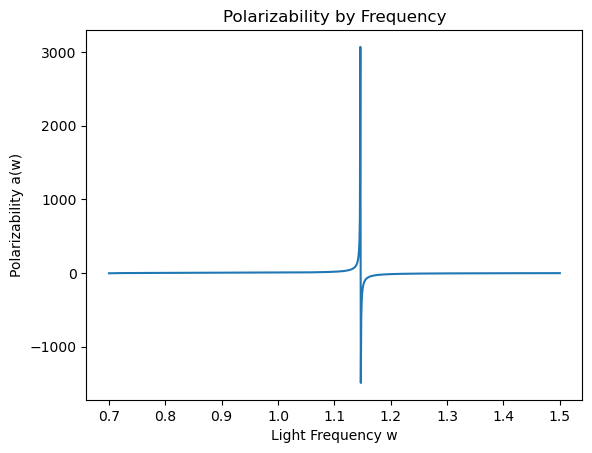

In [92]:
import matplotlib.pyplot as plt

w_values = np.linspace(0.7, 1.5, 1000)
a_values = [solve_alpha(w) for w in w_values]

plt.plot(w_values, a_values)
plt.title("Polarizability by Frequency")
plt.xlabel("Light Frequency w")
plt.ylabel("Polarizability a(w)")
# plt.axvline(x=1.146, color='r', linestyle='--', label='w=1.146', alpha=0.5)
# plt.legend()
plt.show()

#### (2)

Let's look at equation (2) once more:

$$(E -\omega S) x = z$$

The light frequency $\omega$, only affect the left-hand side matrix. Let's also remember what the condition number is: the ratio of the relative change in the solution to the relative change in the input. An ill-conditioned mathematical problem will have a condition number much larger than 1. This number can also be used to bound the forward-error. 

Now let's look at the plot below, which display the condition number for the matrix $E - \omega S$ for the many light frequencies using the function from exercise a). Notice how the condition number gets immensely large as it reaches the $\omega = 1.146307999$ mark, the same mark that happened to cause spikes in the previous exercise. What this crucial piece of information tells us is that at around this frequency, the matrix becomes nearly singular, amplifying the errors, and that the problem at hand becomes too sensitive, to the point where a error bound in $\alpha(\omega)$ can't even give us usable information.

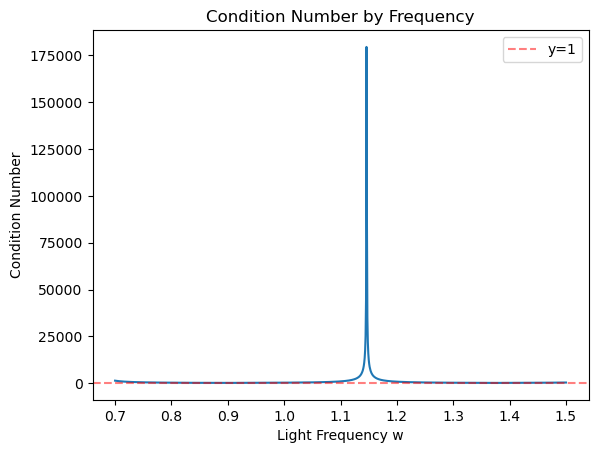

In [93]:
conditionNumbers = [conditionNumber(E - w * S) for w in w_values]

plt.plot(w_values, conditionNumbers)
plt.title("Condition Number by Frequency")
plt.xlabel("Light Frequency w")
plt.ylabel("Condition Number")
plt.axhline(y=1, color='r', linestyle='--', label='y=1', alpha=0.5)
plt.legend()
plt.show()

## Week 2

### Exercise f)

#### (1)

The function `householder_QR_slow(A)` follows Algorithm 3.1 from the course material. For every column $k$ it builds the Householder vector

$$v_k = a_k - \alpha_k e_k, \qquad \alpha_k = -\text{sign}(a_{kk}) \cdot ||a||_2 $$

which in turn defines the reflection 

$$ H_k = I - 2 \frac{v_k v_k^T}{v_k^T v_k}$$

Reflecting the $k$-th column onto the first axis makes everything below the diagonal zero, and after $\min(n, m-1)$ such reflections, `A` is transformerd into the the upper triangular `R` (+ `O`).

Now, to obtain `Q`, we simply multiply those reflections, that is $H_n \cdots H_1 = Q^T$ 

Before finishing the function we also conduct the requested checks which pass on the test case.

In [94]:
np.set_printoptions(precision=3, suppress=True)

def sign(x):
    return 1.0 if x >= 0 else -1.0

def householder_QR_slow(A):
    m, n = A.shape
    R = A.astype(float).copy()
    Q = np.eye(m)

    assert m >= n, "Needs more rows than columns"

    for k in range(min(n, m - 1)):
        a_k = -sign(R[k, k]) * np.sqrt(np.sum(R[k:, k] ** 2))
        v_k = R[k:, k].copy()
        v_k[0] -= a_k
        b_k = v_k.T @ v_k

        if b_k == 0:
            continue

        for j in range(k, n):
            phi_j = v_k @ R[k:, j]
            R[k:, j] -= (2 * phi_j / b_k) * v_k

        for j in range(m):
            phi_j = v_k @ Q[k:, j]
            Q[k:, j] -= (2 * phi_j / b_k) * v_k

    Q = Q.T

    #Checks
    assert np.allclose(Q.T @ Q, np.eye(m)), "Q not orthogonal"
    assert np.allclose(Q.T @ Q, Q @ Q.T), "Q not orthogonal"

    assert np.allclose(Q @ R, A), "M != QR"

    return Q, R

Q, R = householder_QR_slow(testMatrix)

#### (2)

For a more efficient version of the function above, we can ignore the construction of the $m \times m$ `Q` matrix, which is wasteful, and instead only store the reflection vectors `v`, since we can compute $H_k$ from them. The code remains mostly the same, but now we store $v_k$ in the matrix `V` in the column $k$ below the diagonal.

In [95]:
def householder_QR_fast(A):
    m, n = A.shape
    R = A.astype(float).copy()
    V = np.zeros((m, n))

    assert m >= n, "Needs more rows than columns"

    for k in range(min(n, m - 1)):
        a_k = -sign(R[k, k]) * np.sqrt(np.sum(R[k:, k] ** 2))
        v_k = R[k:, k].copy()
        v_k[0] -= a_k
        b_k = v_k @ v_k

        if b_k == 0:
            continue

        for j in range(k, n):
            phi_j = v_k @ R[k:, j]
            R[k:, j] -= (2 * phi_j / b_k) * v_k

        V[k:, k] = v_k

    return V, R

V, R = householder_QR_fast(testMatrix)

#### (3)

In the least squares problem `Ax=b`, the system is overdetermined, that is, $ m \gt n$, and `b` will (almost) never lie in `span(A)`. The best we can do is have a minimal residual error $r = b - A\tilde{x}$.

Since `Q` from the QR factorization of `A` is ortogonal, multiplying by it won't change the length of vectors (including the residual), so we can transform the problem into

$$\min(||b - A\tilde{x}||) = \min(||Q^Tb - Q^TQR\tilde{x}||) = \min(||Q^Tb - R\tilde{x}||)$$

Therefore, with function `least_squares(A,b)`, an approximated solution $\tilde{x}$ that leads to the minimal residual error $r$ are returned.


In [96]:
def least_squares(A, b):
    assert A.shape[0] >= A.shape[1], "More columns than rows"
    assert A.shape[0] == b.shape[0], "A rows != b rows"
    assert b.shape[1] == 1, "b not column vector"

    m, n = A.shape
    Q, R = householder_QR_slow(A)

    QTb = (Q.T @ b).flatten()

    x = back_substitute(R[:n, :n], QTb[:n])
    x = x.reshape(n, 1)

    r = b - A @ x

    return x, r



In [97]:
from HHexamples import A1, b1, x1, A2, b2, x2

m, n = A1.shape

Q, R = householder_QR_slow(A1)

print("R")
print(np.round(R, 3))
print("Q")
print(np.round(Q, 3))

V, R_fast = householder_QR_fast(A1)

print()
print(f"R == R_fast: {np.all(R_fast == R)}")

print()
x, r = least_squares(A1, b1.reshape(-1, 1))

print(f"x = {np.round(x.flatten(), 3)}")
print(f"truth = {np.round(x1, 3)}")


R
[[-5.916 -7.437]
 [ 0.     0.828]
 [ 0.     0.   ]]
Q
[[-0.169  0.897  0.408]
 [-0.507  0.276 -0.816]
 [-0.845 -0.345  0.408]]

R == R_fast: True

x = [0.  0.5]
truth = [-0.   0.5]


### Exercise g)

#### (1)

The polynomial $P(\omega)$ is finite everywhere, therefore it is unsuitable to follow $\alpha(\omega)$ as it approaches the singularity at around $\approx 1.146$ that was refered in earlier exercises. Whatever that is picked for $\omega_p$ must stay outside that frequency. Hence, I arbitrarly choose $\omega_p = 1.1$ as it keeps a decent margin from the danger zone while still covering a good amount of the interval.

#### (2)

Since $P(\omega)$ is a sum of $a_j \omega^{2j}$, it is linear in the coefficients we are looking for so we can use `least_squares(A,b)` to solve it. To construct `A` we take the 500 values from `w_values` (remember exercise e)) that fit inside the range [0.7, 1.1]. Each of these values will represent a row in the matrix `A`, where the columns will be represented by $\omega^{2j}$ and `b` the respective $\alpha_j$ values.


In [98]:
wp = 1.1

mask = w_values <= wp
w_fit = w_values[mask]
a_fit = np.array(a_values)[mask]

def polynomial_fit(w, a, n):
    A = np.zeros((len(w), n + 1))
    for j in range(n + 1):
        A[:, j] = w ** (2 * j)

    c, r = least_squares(A, a.reshape(-1, 1))
    return c.flatten(), r

coefficients_4, residual_4 = polynomial_fit(w_fit, a_fit, n=4)

print(f"{len(w_fit)} points in [0.7, {wp}]")
print(f"coefficients = {np.round(coefficients_4, 4)}")
print(f"residual = {infNorm(residual_4):.4e}")

500 points in [0.7, 1.1]
coefficients = [ -29.202   57.683   60.359 -177.703   94.211]
residual = 1.4120e+00


#### (3)

Using a different `n`, in this case 6, we can compare the results via the relative error $ \frac{|P(\omega) -\alpha(\omega)|}{|\alpha(\omega)|}$, which is plotted below on a $\log_{10}$ scale.

The spike observed at around $\omega \approx 0.73$ can be explained due to the fact that it is when $\alpha(\omega)$ passes through 0, making the relative error formula spike even if the absolute one remains consistent. Other than that spike region, $n=6$ does have some more accuracy that $n=4$ but not a significant gain.

coefficients = [ -504.529  3189.37  -8084.779 10376.801 -6895.86   2096.45   -171.892]
residual = 5.6743e-01


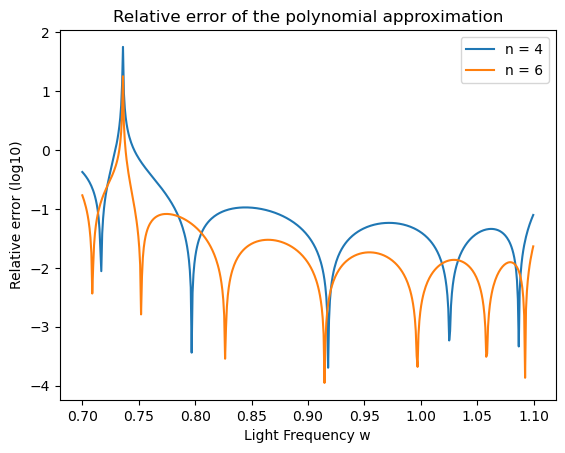

In [99]:
coefficients_6, residual_6 = polynomial_fit(w_fit, a_fit, n=6)

print(f"coefficients = {np.round(coefficients_6, 4)}")
print(f"residual = {infNorm(residual_6):.4e}")

def evaluate_polynomial(coefficients, w):
    n = len(coefficients) - 1

    A = np.zeros((len(w), n + 1))
    for j in range(n + 1):
        A[:, j] = w ** (2 * j)

    return A @ coefficients

P4 = evaluate_polynomial(coefficients_4, w_fit)
P6 = evaluate_polynomial(coefficients_6, w_fit)

relative_4 = np.abs((P4 - a_fit) / a_fit)
relative_6 = np.abs((P6 - a_fit) / a_fit)

plt.plot(w_fit, np.log10(relative_4), label="n = 4")
plt.plot(w_fit, np.log10(relative_6), label="n = 6")
plt.title("Relative error of the polynomial approximation")
plt.xlabel("Light Frequency w")
plt.ylabel("Relative error (log10)")
plt.legend()
plt.show()

#### (4)
Using the same formula as in the first exercises ($\lfloor -\log_{10} E_{rel} \rfloor$), we can calculate the significant digits that the approximations are guaranteed to yield correctly.

Given that an abnormal spike is presented when $\alpha(\omega)$ passes through 0, I present the guaranteed digits for the max and median relative errors for each polynomial within the interval [0.7, 1.1].

| n |$\text{max } E_{rel}$ | $\text{med } E_{rel}$| guaranteed digits | normally guranteed digits |
|---|---|---|---|---|
| 4|56.4045 | 0.0529 |**0** | **1** |
| 6| 17.9187 | 0.0158 | **0**|**1** |

In [100]:

for n, relative in ((4, relative_4), (6, relative_6)):
    maxRelative = relative.max()
    medianRelative = np.median(relative)

    guaranteedDigits = np.floor(-np.log10(abs(maxRelative)))
    guaranteedDigits = max(0, guaranteedDigits)

    typicalDigits = np.floor(-np.log10(abs(medianRelative)))
    typicalDigits = max(0, typicalDigits)

    print(f"n={n}")
    print(f"max rel error = {maxRelative:.4f}")
    print(f"med rel error = {medianRelative:.4f}")
    print(f"guaranteed digits = {guaranteedDigits:.0f}")
    print(f"typical digits = {typicalDigits:.0f}")
    print("\n")

n=4
max rel error = 56.4045
med rel error = 0.0529
guaranteed digits = 0
typical digits = 1


n=6
max rel error = 17.9187
med rel error = 0.0158
guaranteed digits = 0
typical digits = 1




### Exercise h)

#### (1)
The polynomial $P(\omega)$ used in the previous exercise is a finite sum of powers, so it would never be able to produce a singularity. That is not the same for the equation (5) (depicted below), which has another polynomial at the denominator. Whenever $\alpha(\omega)$ presents a singularity, this new equation simply needs to vanish that new polynomial, making $Q(\omega)$ go to infinity as well

$$Q(\omega) = \frac{\sum_{j=0}^n a_j\omega^j}{1 + \sum_{j=1}^n b_j\omega^j}$$


#### (2)

Before considering using `least_squares(A,b)`, it is important to understand that it only works with linear combinations, which is not the case of $Q(\omega)$. Howver, with some reformulation, we can transform it into a linear one in form of `Ax = b`

$$\alpha(\omega) = \frac{\sum_{j=0}^n a_j\omega^j}{1 + \sum_{j=1}^n b_j\omega^j}$$

$$\equiv \alpha(\omega) \cdot (1 + \sum_{j=1}^n b_j\omega^j) = \sum_{j=0}^n a_j\omega^j$$

$$\equiv \alpha(\omega) + \sum_{j=1}^n \alpha(\omega) b_j\omega^j = \sum_{j=0}^n a_j\omega^j$$

$$\equiv \alpha(\omega) = \sum_{j=0}^n a_j\omega^j - \sum_{j=1}^n \alpha(\omega) b_j\omega^j$$

Constructing this into matrix form is a similar process to what we have done before. Each row of `A` represents one value of $\omega$, the first $n+1$ columns are represented by the first summatory, that is $\omega^j$, and the following $n$ by the next one, $-\alpha(\omega)\omega^j$. `b` will obviously hold all the $\alpha(\omega)$ values and the resulting vector will hold both $a$ and $b$ coefficients in a serial manner.


a = [ 1.928 -3.453  1.144]
b = [-2.394  1.327]
residual = 6.4814e-02


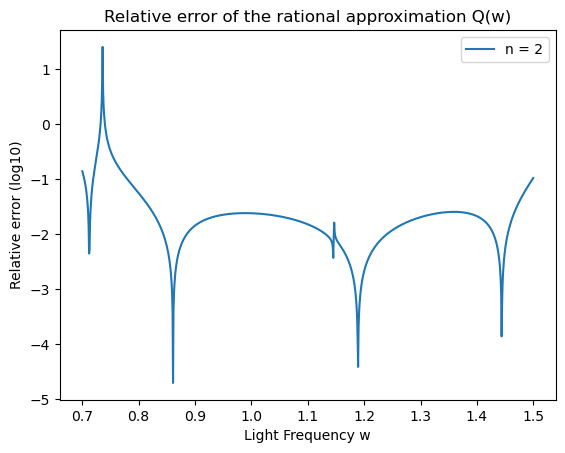

In [101]:
w_all = w_values
alpha_all = np.array(a_values)

def rational_fit(w, a, n):
    A = np.zeros((len(w), 2 * n + 1))
    for j in range(n + 1):
        A[:, j] = w ** j
    for j in range(1, n + 1):
        A[:, n + j] = -a * (w ** j)

    c, r = least_squares(A, a.reshape(-1, 1))
    c = c.flatten()
    return c[:n + 1], c[n + 1:], r

def rebuild_rational(av, bv, w):
    numerator = np.zeros(len(w))
    for j in range(len(av)):
        numerator += av[j] * w ** j

    denominator = np.ones(len(w))
    for j in range(1, len(bv) + 1):
        denominator += bv[j - 1] * w ** j

    return numerator / denominator

a_2, b_2, residual_2 = rational_fit(w_all, alpha_all, n=2)

print(f"a = {np.round(a_2, 4)}")
print(f"b = {np.round(b_2, 4)}")
print(f"residual = {infNorm(residual_2):.4e}")

Q2 = rebuild_rational(a_2, b_2, w_all)
relative_Q2 = np.abs((Q2 - alpha_all) / alpha_all)

plt.plot(w_all, np.log10(relative_Q2), label="n = 2")
plt.title("Relative error of the rational approximation Q(w)")
plt.xlabel("Light Frequency w")
plt.ylabel("Relative error (log10)")
plt.legend()
plt.show()

#### (3)

Repeating the same experiment but with $n=4$ shows a decent difference in the extra freedom the rational function has. Even with the same relative error spike that was present in g), $Q(\omega)$ at $n=4$ is still able to guarantee digits regardless of where in the interval we compute (although this may change if we use a more fine linear space)

| n  | max $E_{rel}$  | med $E_{rel}$ | guaranteed digits | typical digits |
| ---  | ---  | --- | --- | ---|
| 2 | 2.5641e+01 | 2.0408e-02 | **0**| **1** |
| 4 | 1.8420e-04 | 1.1848e-07 | **3**| **6** |

a = [ 1.972 -3.894  1.614  0.055 -0.009]
b = [-2.    -0.171  1.921 -0.798]
residual = 1.6896e-07


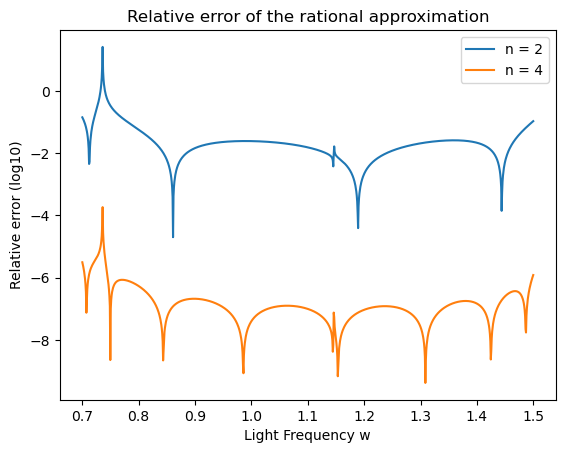

n=2
max rel error = 2.5641e+01
med rel error = 2.0408e-02
guaranteed digits = 0
typical digits = 1


n=4
max rel error = 1.8420e-04
med rel error = 1.1848e-07
guaranteed digits = 3
typical digits = 6




In [102]:
a_4, b_4, residual_4_h = rational_fit(w_all, alpha_all, n=4)

print(f"a = {np.round(a_4, 4)}")
print(f"b = {np.round(b_4, 4)}")
print(f"residual = {infNorm(residual_4_h):.4e}")

Q4 = rebuild_rational(a_4, b_4, w_all)
relative_Q4 = np.abs((Q4 - alpha_all) / alpha_all)

plt.plot(w_all, np.log10(relative_Q2), label="n = 2")
plt.plot(w_all, np.log10(relative_Q4), label="n = 4")
plt.title("Relative error of the rational approximation")
plt.xlabel("Light Frequency w")
plt.ylabel("Relative error (log10)")
plt.legend()
plt.show()


for n, relative in ((2, relative_Q2), (4, relative_Q4)):
    print(f"n={n}")
    print(f"max rel error = {relative.max():.4e}")
    print(f"med rel error = {np.median(relative):.4e}")
    print(f"guaranteed digits = {max(0, np.floor(-np.log10(np.max(relative)))):.0f}")
    print(f"typical digits = {max(0, np.floor(-np.log10(np.median(relative)))):.0f}")
    print("\n")


#### (4)

As we can see via the first code cell below, in the interval $[-4, 4]$ there are 6 singularities instead of just 1. The denominator of the rational function $Q(\omega)$ is a polynomial of degree $n$, so it has at most $n$ roots, and therefore $Q(\omega)$ can only represent $n$ singularities correctly. So, we simply need to raise $n$ to 6. Below are some results with these experiments.

| n | max $E_{rel}$ | med $E_{rel}$ | singularities marked |
| --- | --- | --- | --- |
| 2 | 2.6048e+02 | 4.1407e-01 | 2/6 |
| 4 | 2.0975e+02 | 9.8112e-02 | 4/6 |
| 6 |  1.2247e+00| 6.9287e-04 | 6/6 |
| 8 | 9.1396e-05 | 8.7228e-08 | 6/6 |

As predicted, any $n \lt 6$ can't fully reproduce all the singularities, which is why the max error is so large. From $n=6$ onwards all poles are found correctly, and at $n=8$ some roots are placed outside the interval as well, which don't do any harm in this case

*Note: If we notice, the poles are all symetric, meaning that if we wanted to optimize the function Q(w) we could simply consider even polynomials, reducing the size of the matrices and hence calculations*

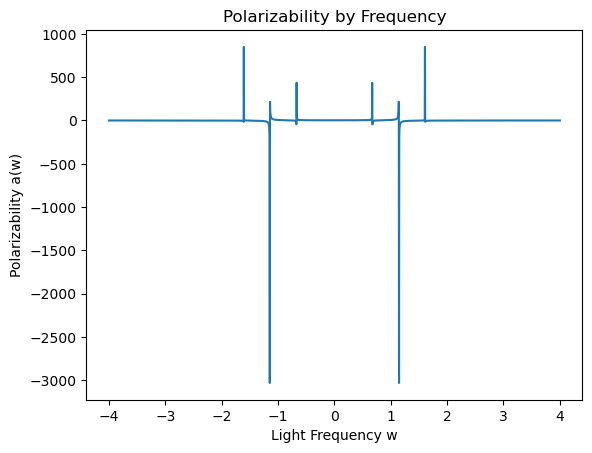

In [103]:
w_ext = np.linspace(-4, 4, 2000)
alpha_ext = np.array([solve_alpha(w) for w in w_ext])

plt.plot(w_ext, alpha_ext)
plt.title("Polarizability by Frequency")
plt.xlabel("Light Frequency w")
plt.ylabel("Polarizability a(w)")
plt.show()

n=2
max rel error = 2.6048e+02
med rel error = 4.1407e-01
poles = [-1.215  1.215]


n=4
max rel error = 2.0975e+02
med rel error = 9.8112e-02
poles = [-1.593 -1.139  1.139  1.593]


n=6
max rel error = 1.2247e+00
med rel error = 6.9287e-04
poles = [-1.607 -1.146 -0.671  0.671  1.146  1.607]


n=8
max rel error = 9.1396e-05
med rel error = 8.7228e-08
poles = [-8.598 -1.607 -1.146 -0.671  0.671  1.146  1.607  8.598]




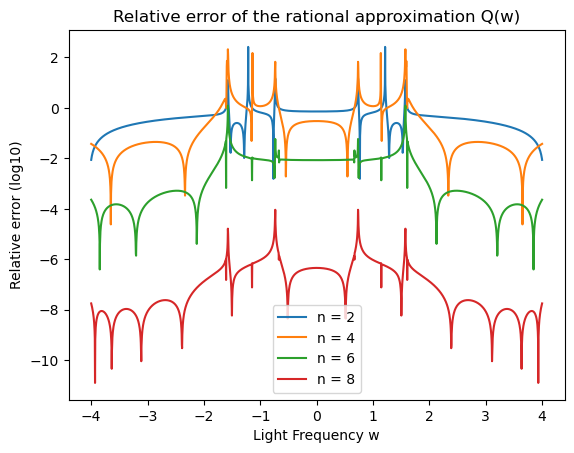

In [106]:
w_ext = np.linspace(-4, 4, 2000)
alpha_ext = np.array([solve_alpha(w) for w in w_ext])

for n in (2, 4, 6, 8):
    a_n, b_n, residual_n = rational_fit(w_ext, alpha_ext, n)
    Q = rebuild_rational(a_n, b_n, w_ext)
    relative = np.abs((Q - alpha_ext) / alpha_ext)

    denominator = np.concatenate(([1.0], b_n))
    poles = np.roots(denominator[::-1])
    poles = np.sort(poles[np.abs(poles.imag) < 1e-8].real)

    print(f"n={n}")
    print(f"max rel error = {relative.max():.4e}")
    print(f"med rel error = {np.median(relative):.4e}")
    print(f"poles = {np.round(poles, 4)}")
    print("\n")

    plt.plot(w_ext, np.log10(relative), label=f"n = {n}")

plt.title("Relative error of the rational approximation Q(w)")
plt.xlabel("Light Frequency w")
plt.ylabel("Relative error (log10)")
plt.legend()
plt.show()